In [1]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["font.size"] = 12


In [2]:
# 修改成你的实际路径
BASE_DIR = r"C:\Users\yangy\reproduction\new_results\doublecheck"

pattern = os.path.join(BASE_DIR, "rep_*_doublecheck.csv")
file_list = sorted(glob.glob(pattern))

print(f"找到 {len(file_list)} 个 doublecheck CSV 文件")
file_list[:5]


找到 100 个 doublecheck CSV 文件


['C:\\Users\\yangy\\reproduction\\new_results\\doublecheck\\rep_000_doublecheck.csv',
 'C:\\Users\\yangy\\reproduction\\new_results\\doublecheck\\rep_001_doublecheck.csv',
 'C:\\Users\\yangy\\reproduction\\new_results\\doublecheck\\rep_002_doublecheck.csv',
 'C:\\Users\\yangy\\reproduction\\new_results\\doublecheck\\rep_003_doublecheck.csv',
 'C:\\Users\\yangy\\reproduction\\new_results\\doublecheck\\rep_004_doublecheck.csv']

In [3]:
dfs = [pd.read_csv(f) for f in file_list]

# 检查列名是否正常
dfs[0].head()
# 检查 x 是否在所有 rep 中一致
x0 = dfs[0]["x"].values
for i, df in enumerate(dfs[1:], start=1):
    if not np.allclose(x0, df["x"].values):
        raise ValueError(f"x grid mismatch between file 0 and file {i}")

x = x0
R = len(dfs)
J = len(x)

print(f"R = {R}, J = {J}")


R = 100, J = 50


In [4]:
# [R, J] 经验 double-check 覆盖 (0/1)
cov_emp = np.vstack([df["cov_indicator"].values for df in dfs])

# [R, J] calibration 那边估计出来的 coverage (一般是 0.xx)
cov_calib = np.vstack([df["cov_at_alpha_star_calib"].values for df in dfs])

emp_mean = cov_emp.mean(axis=0)
emp_sd   = cov_emp.std(axis=0)

calib_mean = cov_calib.mean(axis=0)
calib_sd   = cov_calib.std(axis=0)

emp_mean[:5], calib_mean[:5]


(array([0.83, 1.  , 0.8 , 0.7 , 0.98]),
 array([0.98175, 0.99695, 0.99045, 0.98595, 0.99575]))

In [5]:
summary = pd.DataFrame({
    "x": x,
    "emp_cov_mean": emp_mean,
    "emp_cov_sd":   emp_sd,
    "calib_cov_mean": calib_mean,
    "calib_cov_sd":   calib_sd,
})

out_csv = os.path.join(BASE_DIR, "alpha_star_doublecheck_summary_local.csv")
summary.to_csv(out_csv, index=False)
out_csv


'C:\\Users\\yangy\\reproduction\\new_results\\doublecheck\\alpha_star_doublecheck_summary_local.csv'

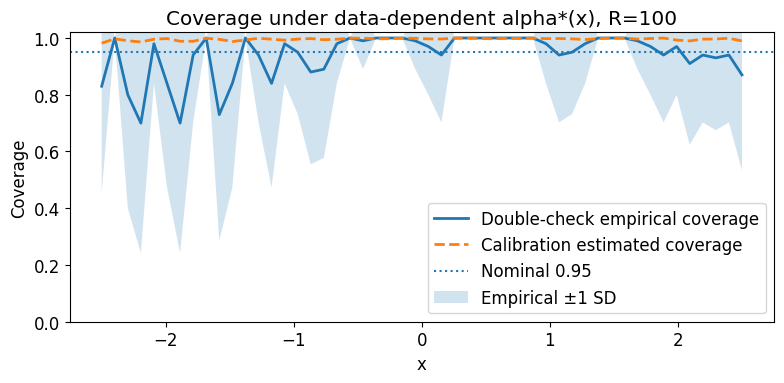

In [6]:
plt.figure()

plt.plot(x, emp_mean, label="Double-check empirical coverage", linewidth=2)
plt.plot(x, calib_mean, "--", label="Calibration estimated coverage", linewidth=2)
plt.axhline(0.95, linestyle=":", label="Nominal 0.95")

# 给 double-check 画一个 ±1 SD 的阴影（看看 across reps 波动多大）
plt.fill_between(x,
                 emp_mean - emp_sd,
                 emp_mean + emp_sd,
                 alpha=0.2,
                 label="Empirical ±1 SD")

plt.xlabel("x")
plt.ylabel("Coverage")
plt.ylim(0.0, 1.02)
plt.title(f"Coverage under data-dependent alpha*(x), R={R}")
plt.legend()
plt.tight_layout()
plt.show()


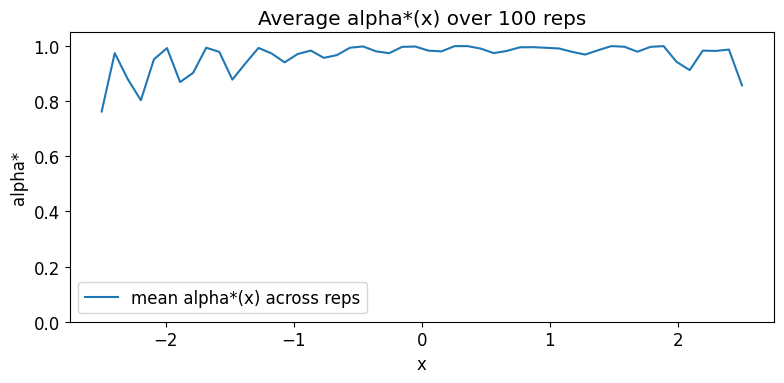

In [7]:
# [R, J] alpha_star，每个 rep 的 alpha*
alpha_star = np.vstack([df["alpha_star"].values for df in dfs])

alpha_mean = alpha_star.mean(axis=0)

plt.figure()
plt.plot(x, alpha_mean, label="mean alpha*(x) across reps")
plt.xlabel("x")
plt.ylabel("alpha*")
plt.title("Average alpha*(x) over 100 reps")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
print("整体平均覆盖（double-check, 所有 x 和 rep 上）：", cov_emp.mean())
print("每个 x 上的最小 / 最大经验覆盖：", emp_mean.min(), emp_mean.max())
j_bad = emp_mean.argmin()
print("emp_mean 最低的那个点 index =", j_bad, ", x =", x[j_bad])
print("该点 double-check 覆盖均值 =", emp_mean[j_bad])

vals = cov_emp[:, j_bad]    # 100 个 rep 上的 0/1
print("该点 0 的个数 =", (vals == 0).sum())
print("该点 1 的个数 =", (vals == 1).sum())
print("原始 0/1 序列：", vals)
per_rep_mean = cov_emp.mean(axis=1)  # 每个 rep 的整体平均覆盖率
print("每个 rep 平均覆盖的最小/最大值：", per_rep_mean.min(), per_rep_mean.max())

all_ones_mask = (cov_emp == 1).all(axis=1)
print("完全全覆盖的 rep 数量:", all_ones_mask.sum(), "/", R)

# 看看不是全覆盖的那些 rep 平均覆盖率
print("非全覆盖 rep 的平均覆盖率：",
      per_rep_mean[~all_ones_mask].mean() if (~all_ones_mask).any() else "无")


整体平均覆盖（double-check, 所有 x 和 rep 上）： 0.9404
每个 x 上的最小 / 最大经验覆盖： 0.7 1.0
emp_mean 最低的那个点 index = 3 , x = -2.193877551020408
该点 double-check 覆盖均值 = 0.7
该点 0 的个数 = 30
该点 1 的个数 = 70
原始 0/1 序列： [1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1.
 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 0. 0. 1.
 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1.
 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0.
 1. 1. 0. 1.]
每个 rep 平均覆盖的最小/最大值： 0.62 1.0
完全全覆盖的 rep 数量: 58 / 100
非全覆盖 rep 的平均覆盖率： 0.858095238095238


找到 100 个 doublecheck CSV 文件
['C:\\Users\\yangy\\reproduction\\new_results\\doublecheck\\rep_000_doublecheck.csv', 'C:\\Users\\yangy\\reproduction\\new_results\\doublecheck\\rep_001_doublecheck.csv', 'C:\\Users\\yangy\\reproduction\\new_results\\doublecheck\\rep_002_doublecheck.csv', 'C:\\Users\\yangy\\reproduction\\new_results\\doublecheck\\rep_003_doublecheck.csv', 'C:\\Users\\yangy\\reproduction\\new_results\\doublecheck\\rep_004_doublecheck.csv']
R = 100, J = 50
前 5 个点的 double-check mean / calib mean：
[0.83 1.   0.8  0.7  0.98] [0.98175 0.99695 0.99045 0.98595 0.99575]
保存 summary 到： C:\Users\yangy\reproduction\new_results\doublecheck\alpha_star_doublecheck_summary_local.csv
找到 100 个 calibration csv 文件
baseline 使用的列名：alpha_1.0000 (alpha=1.0)
baseline 覆盖数组形状: R_calib=100, J=50


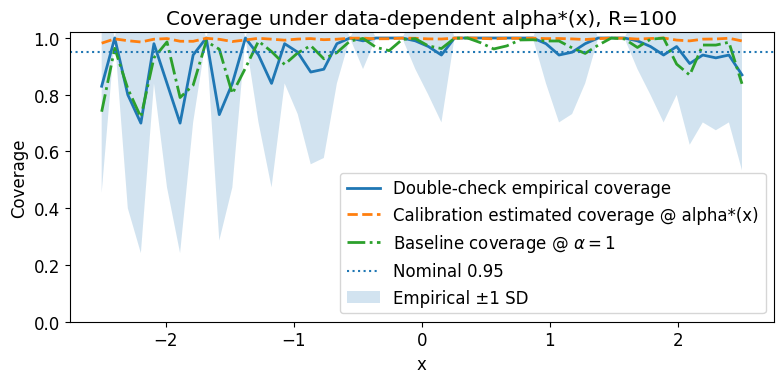

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["font.size"] = 12

# =========================
# 1. 读取 double-check 结果
# =========================
BASE_DIR = r"C:\Users\yangy\reproduction\new_results\doublecheck"

pattern = os.path.join(BASE_DIR, "rep_*_doublecheck.csv")
file_list = sorted(glob.glob(pattern))

print(f"找到 {len(file_list)} 个 doublecheck CSV 文件")
print(file_list[:5])

dfs = [pd.read_csv(f) for f in file_list]

# 检查 x 是否在所有 rep 中一致
x0 = dfs[0]["x"].values
for i, df in enumerate(dfs[1:], start=1):
    if not np.allclose(x0, df["x"].values):
        raise ValueError(f"x grid mismatch between file 0 and file {i}")

x = x0
R = len(dfs)
J = len(x)

print(f"R = {R}, J = {J}")

# [R, J] double-check 经验覆盖 (0/1)
cov_emp = np.vstack([df["cov_indicator"].values for df in dfs])

# [R, J] calibration 阶段对 alpha*(x) 的 coverage 估计
cov_calib = np.vstack([df["cov_at_alpha_star_calib"].values for df in dfs])

emp_mean = cov_emp.mean(axis=0)
emp_sd   = cov_emp.std(axis=0)

calib_mean = cov_calib.mean(axis=0)
calib_sd   = cov_calib.std(axis=0)

print("前 5 个点的 double-check mean / calib mean：")
print(emp_mean[:5], calib_mean[:5])

summary = pd.DataFrame({
    "x": x,
    "emp_cov_mean": emp_mean,
    "emp_cov_sd":   emp_sd,
    "calib_cov_mean": calib_mean,
    "calib_cov_sd":   calib_sd,
})

out_csv = os.path.join(BASE_DIR, "alpha_star_doublecheck_summary_local.csv")
summary.to_csv(out_csv, index=False)
print("保存 summary 到：", out_csv)

# =====================================
# 2. 从 two_split 结果里取 baseline α=1
# =====================================
ROOT_DIR = r"C:\Users\yangy\two_split\results"

# 这一段就是你之前的 pattern，直接复用
calib_pattern = os.path.join(ROOT_DIR, "rep_*", "pointwise_coverage_rep*_A*_B*.csv")
calib_files = sorted(glob.glob(calib_pattern))

print(f"找到 {len(calib_files)} 个 calibration csv 文件")
assert len(calib_files) > 0, "没有匹配到 calibration 文件，检查 ROOT_DIR 和 calib_pattern"

# 读第一个文件：拿到 x 网格和 alpha 列名
first_df = pd.read_csv(calib_files[0])
x_calib = first_df["x"].values

# 确认 x 网格和 double-check 一致
if not np.allclose(x_calib, x):
    raise ValueError("two_split 的 x 网格与 doublecheck 不一致")

alpha_cols = [c for c in first_df.columns if c != "x"]  # 比如 alpha_0.01, alpha_0.02, ..., alpha_1.0
alphas = np.array([float(c.split("_")[1]) for c in alpha_cols])

# 找到 alpha = 1.0 对应的列名
idx_one = np.where(np.isclose(alphas, 1.0))[0]
if len(idx_one) == 0:
    raise ValueError("在 alpha 列里没找到 alpha=1.0，对一下列名和数值")
idx_one = idx_one[0]
col_alpha1 = alpha_cols[idx_one]
print(f"baseline 使用的列名：{col_alpha1} (alpha={alphas[idx_one]})")

# 堆叠所有 rep 的 α=1 覆盖 -> [R_calib, J]
baseline_list = []
for fname in calib_files:
    df = pd.read_csv(fname)

    if not np.allclose(df["x"].values, x):
        raise ValueError(f"x 网格在文件 {os.path.basename(fname)} 中不一致")

    vals = df[col_alpha1].values  # [J]
    baseline_list.append(vals)

baseline_arr = np.stack(baseline_list, axis=0)  # [R_calib, J]
R_calib = baseline_arr.shape[0]
print(f"baseline 覆盖数组形状: R_calib={R_calib}, J={baseline_arr.shape[1]}")

baseline_mean = baseline_arr.mean(axis=0)
baseline_sd   = baseline_arr.std(axis=0)

# ====================
# 3. 画三条 curve 对比
# ====================
plt.figure()

plt.plot(x, emp_mean, label="Double-check empirical coverage", linewidth=2)
plt.plot(x, calib_mean, "--", label="Calibration estimated coverage @ alpha*(x)", linewidth=2)
plt.plot(x, baseline_mean, "-.", label=r"Baseline coverage @ $\alpha=1$", linewidth=2)

plt.axhline(0.95, linestyle=":", label="Nominal 0.95")

# 给 double-check 画一个 ±1 SD 的阴影
plt.fill_between(
    x,
    emp_mean - emp_sd,
    emp_mean + emp_sd,
    alpha=0.2,
    label="Empirical ±1 SD"
)

plt.xlabel("x")
plt.ylabel("Coverage")
plt.ylim(0.0, 1.02)
plt.title(f"Coverage under data-dependent alpha*(x), R={R}")
plt.legend()
plt.tight_layout()
plt.show()
